In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


In [2]:
INPUT_DIM = 3072
HIDDEN_DIM = 512

BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.001

SPARSITY_TARGET = 0.05
SPARSITY_WEIGHT = 0.001

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [3]:
transform = transforms.ToTensor()

train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))
print("Image shape:", train_data[0][0].shape)

100%|██████████| 170M/170M [00:10<00:00, 15.8MB/s]


Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])


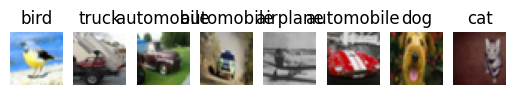

In [4]:
classes = train_data.classes
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8)

for i in range(8):
    img = images[i]
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis("off")

plt.show()

In [5]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.decoder = nn.Linear(HIDDEN_DIM, INPUT_DIM)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        encoded = torch.sigmoid(self.encoder(x))
        decoded = torch.sigmoid(self.decoder(encoded))

        return encoded, decoded


model = SparseAutoencoder()

dummy_input = torch.zeros(4, 3, 32, 32)
enc_out, dec_out = model(dummy_input)

print("Encoder output:", enc_out.shape)
print("Decoder output:", dec_out.shape)

print(model)

Encoder output: torch.Size([4, 512])
Decoder output: torch.Size([4, 3072])
SparseAutoencoder(
  (encoder): Linear(in_features=3072, out_features=512, bias=True)
  (decoder): Linear(in_features=512, out_features=3072, bias=True)
)


In [6]:
def kl_divergence(rho, rho_hat):

    rho = torch.tensor(rho).to(rho_hat.device)
    rho_hat = torch.clamp(rho_hat, 1e-8, 1 - 1e-8)

    kl = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return kl


rho = 0.05
rho_hat = torch.tensor([0.05, 0.10, 0.50, 0.90])

kl = kl_divergence(rho, rho_hat)

print("KL values:", kl)

KL values: tensor([0.0000, 0.0167, 0.4946, 1.9942])


In [7]:
def train_one_epoch(model, loader, optimizer, epoch):

    model.train()
    total_loss = 0

    for images, _ in loader:
        images = images.to(DEVICE)

        encoded, decoded = model(images)

        images = images.view(images.size(0), -1)
        recon_loss = nn.functional.mse_loss(decoded, images)

        rho_hat = encoded.mean(0)
        sparsity_loss = kl_divergence(SPARSITY_TARGET, rho_hat).sum()

        loss = recon_loss + SPARSITY_WEIGHT * sparsity_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print("Epoch", epoch, "Loss:", avg_loss)

    return avg_loss


In [8]:
model = SparseAutoencoder().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Training started")

losses = []

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader, optimizer, epoch + 1)
    losses.append(loss)

print("Training finished")

Training started
Epoch 1 Loss: 0.056237505235690245
Epoch 2 Loss: 0.03394673269584167
Epoch 3 Loss: 0.026525130267350042
Epoch 4 Loss: 0.022932937615836153
Epoch 5 Loss: 0.020663133584799206
Epoch 6 Loss: 0.019012890062389935
Epoch 7 Loss: 0.01780927606991359
Epoch 8 Loss: 0.016915134396594093
Epoch 9 Loss: 0.015967787756603593
Epoch 10 Loss: 0.015370528650831203
Epoch 11 Loss: 0.014718644216428605
Epoch 12 Loss: 0.014186910942805057
Epoch 13 Loss: 0.013695108480941581
Epoch 14 Loss: 0.013174132600768792
Epoch 15 Loss: 0.012943765576168591
Epoch 16 Loss: 0.012420257330130862
Epoch 17 Loss: 0.012122360167416687
Epoch 18 Loss: 0.011801603254957162
Epoch 19 Loss: 0.0115572303172429
Epoch 20 Loss: 0.01126859970010665
Training finished


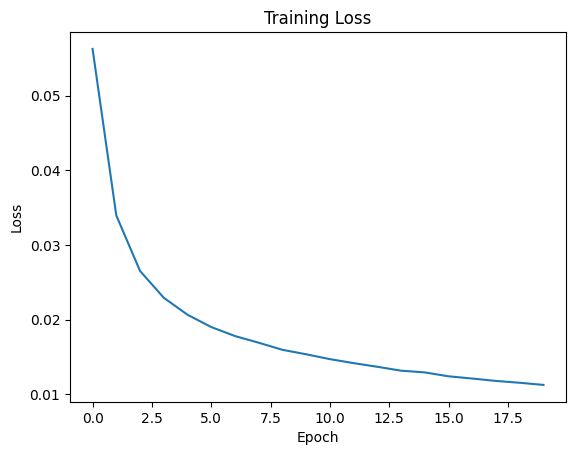

In [9]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [10]:
def evaluate(model, loader):

    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)

            _, decoded = model(images)

            images = images.view(images.size(0), -1)
            loss = nn.functional.mse_loss(decoded, images)

            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print("Test Loss:", avg_loss)

    return avg_loss


test_loss = evaluate(model, test_loader)

Test Loss: 0.01041993263643235


In [11]:
def visualise(model, loader, n=8):

    model.eval()

    images, _ = next(iter(loader))
    images = images[:n].to(DEVICE)

    with torch.no_grad():
        _, decoded = model(images)

    orig = images.cpu()
    recon = decoded.view(-1, 3, 32, 32).cpu()

    fig, axes = plt.subplots(2, n)

    for i in range(n):
        axes[0, i].imshow(orig[i].permute(1, 2, 0))
        axes[0, i].axis("off")

        axes[1, i].imshow(recon[i].permute(1, 2, 0))
        axes[1, i].axis("off")

    plt.show()

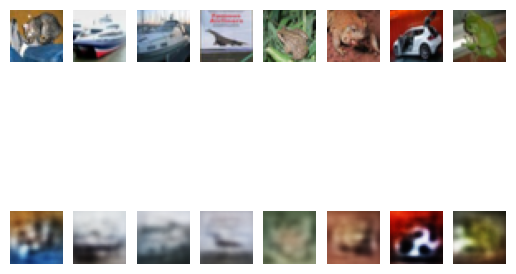

In [12]:
visualise(model, test_loader)

Running sparsity experiment
Beta: 0
Test Loss: 0.01085578661877662


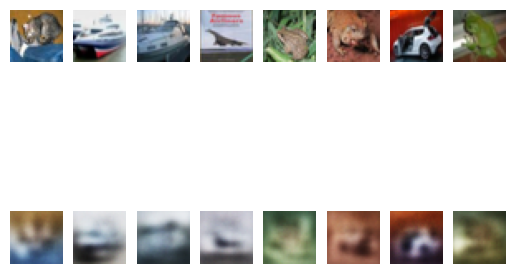

Beta: 0.0001
Test Loss: 0.012488469434902071


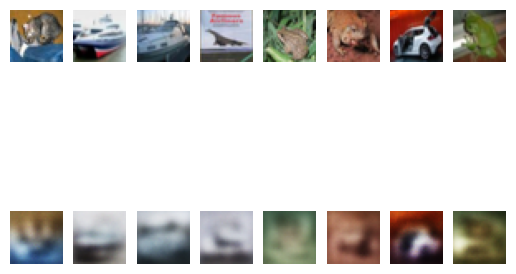

Beta: 0.001
Test Loss: 0.018619728880003093


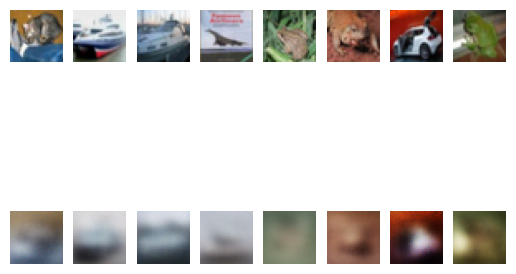

Beta: 0.01
Test Loss: 0.026684492407366634


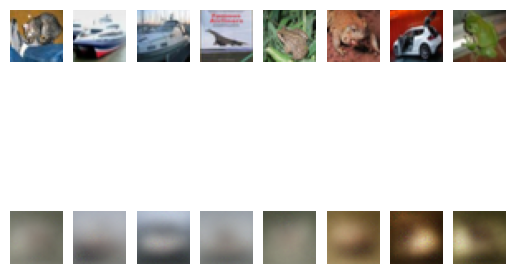

Experiment finished


In [13]:
beta_values = [0, 0.0001, 0.001, 0.01]
test_losses = {}

print("Running sparsity experiment")

for beta in beta_values:
    print("Beta:", beta)

    model = SparseAutoencoder().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(5):
        for images, _ in train_loader:
            images = images.to(DEVICE)

            encoded, decoded = model(images)

            images = images.view(images.size(0), -1)
            recon_loss = nn.functional.mse_loss(decoded, images)

            rho_hat = encoded.mean(0)
            sparsity_loss = kl_divergence(SPARSITY_TARGET, rho_hat).sum()

            loss = recon_loss + beta * sparsity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    test_loss = evaluate(model, test_loader)
    test_losses[beta] = test_loss

    visualise(model, test_loader)

print("Experiment finished")

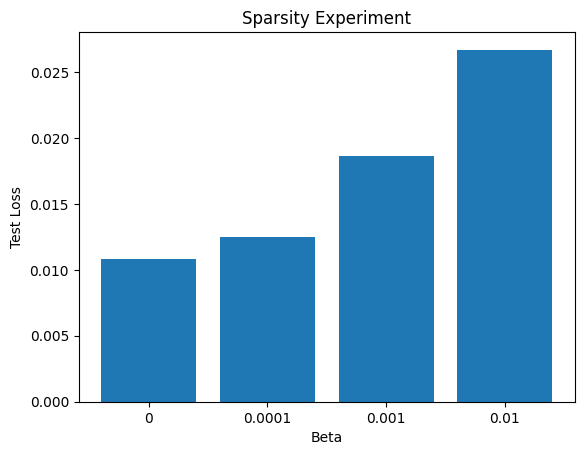

In [14]:
values = [test_losses[b] for b in beta_values]

plt.bar(range(len(beta_values)), values)

plt.xticks(range(len(beta_values)), beta_values)
plt.xlabel("Beta")
plt.ylabel("Test Loss")
plt.title("Sparsity Experiment")

plt.show()